# RadCalNet Automated Multi-Site Processing & Calibration Timeline
### Radiometric Validation of Bottom-of-Atmosphere (BOA) vs. Top-of-Atmosphere (TOA) Reflectance

| Contributor Information | Details |
| :--- | :--- |
| **Author** | Paul Montesano |
| **Affiliation** | NASA GSFC | ESSIC] |
| **Date** | July 9, 2026 |

---

### Notebook Description

This notebook establishes an automated data ingestion and visualization pipeline for processing sequential hyper-spectral measurements from the **Radiometric Calibration Network (RadCalNet)**. It programmatically crawls nested cloud repository structures, extracts multi-dataset chunks from individual file stages, isolates raw measurements from atmospheric uncertainty blocks, and handles internal NoData data fill values (`9997`, `9998`, `9999`).

The core analytical framework transforms wide-format data matrices into long-form datasets to enable comparative multi-site analysis across global calibration targets, specifically focusing on **Railroad Valley, USA (`RVUS`)** and **La Crau, France (`LCFR`)**. 

#### Implemented Visualization Engines:
1. **True-Color & Infrared Timelines (`plot_boa_vs_toa_with_colors`)**: Generates linear multi-band timelines tracking visible and SWIR bands (encoded via real physical wavelengths alongside a customized Burgundy-to-Rust infrared palette) with structural data gaps preserved natively.
2. **Full Spectral Signature Profiles (`plot_spectral_signature_curve`)**: Features continuous 400–2500 nm curves for selected satellite overpasses, applying a localized fuzzy date-matching filter to extract data for different global positions.
3. **Atmospheric Radiation Deficit Profiles (`plot_atmospheric_attenuation`)**: Isolates and graphs the delta values ($\Delta = \text{TOA} - \text{BOA}$) over time to model true atmospheric attenuation independent of surface targets.
4. **Diurnal Solar Cycle Overlays (`plot_diurnal_overlay`)**: Stacks multi-year observations against an identical **HH:MM UTC** daily clock axis to visually highlight ground-reflectance changes caused by solar zenith and azimuth geometric paths.


In [1]:
#pip install radcalnet

In [2]:
import os
import io
import datetime
import configparser
import pandas as pd
import requests

import sys
import subprocess
import configparser
import glob
import pandas as pd

In [3]:
# Map human-readable Site Names to short directory Site Codes
SITE_NAME_TO_CODE = {
    "Railroad Valley": "RVUS",
    "La Crau": "LCFR",
    "Gobabeb": "GONA",
    "Baotou": "BTCN",
    "Baotou Sand": "BSCN",
    "Gobabeb Sand": "GSCN"
}

# Reverse lookup for automatically converting codes back to descriptive titles
SITE_CODE_TO_NAME = {v: k for k, v in SITE_NAME_TO_CODE.items()}
SITE_CODE_TO_NAME

{'RVUS': 'Railroad Valley',
 'LCFR': 'La Crau',
 'GONA': 'Gobabeb',
 'BTCN': 'Baotou',
 'BSCN': 'Baotou Sand',
 'GSCN': 'Gobabeb Sand'}

In [5]:
ADAPT = True

In [62]:
# 1. Safely load credentials from your local file
config = configparser.ConfigParser()

YEAR = "2026"
START_DATE = f"{YEAR}-05-01"
STOP_DATE = f"{YEAR}-06-08"

if ADAPT:
    config.read("/home/pmontesa/code/credentials.ini")
    DATADIR = "/explore/nobackup/projects/CSDA_eval/data/radcalnet"
else:
    config.read("/projects/my-private-bucket/credentials.ini")
    DATADIR = "/projects/my-public-bucket/databank/radcalnet"

In [9]:
# 3. Import and execute the script's main function
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
import radcalnet_api_client

In [13]:
for SITE_CODE in SITE_CODE_TO_NAME.keys():
    
    OUTDIR = f"{DATADIR}/{SITE_CODE}/{YEAR}"
    !mkdir -p $OUTDIR
    
    # 2. Mimic terminal inputs to trigger the main() loop directly
    sys.argv = [
        "radcalnet_api_client.py",
        "--username", config["RadCalNet"]["username"],
        "--password", config["RadCalNet"]["password"],
        "--site", SITE_CODE, 
        "--start-date", START_DATE,
        "--stop-date", STOP_DATE,
        "--fmt", "ascii",
        "--output-dir", f"{OUTDIR}"
    ]
    
    radcalnet_api_client.main()

RVUS00_2026_121_v00.06.input
RVUS00_2026_121_v04.06.output
RVUS00_2026_126_v00.06.input
RVUS00_2026_126_v04.06.output
RVUS00_2026_127_v00.06.input
RVUS00_2026_127_v04.06.output
RVUS00_2026_128_v00.06.input
RVUS00_2026_128_v04.06.output
RVUS00_2026_129_v00.06.input
RVUS00_2026_129_v04.06.output
RVUS00_2026_130_v00.06.input
RVUS00_2026_130_v04.06.output
RVUS00_2026_131_v00.06.input
RVUS00_2026_131_v04.06.output
RVUS00_2026_132_v00.06.input
RVUS00_2026_132_v04.06.output
RVUS00_2026_133_v00.06.input
RVUS00_2026_133_v04.06.output
RVUS00_2026_134_v00.06.input
RVUS00_2026_134_v04.06.output
RVUS00_2026_135_v00.06.input
RVUS00_2026_135_v04.06.output
RVUS00_2026_136_v00.06.input
RVUS00_2026_136_v04.06.output
RVUS00_2026_137_v00.06.input
RVUS00_2026_137_v04.06.output
RVUS00_2026_138_v00.06.input
RVUS00_2026_138_v04.06.output
RVUS00_2026_139_v00.06.input
RVUS00_2026_139_v04.06.output
RVUS00_2026_140_v00.06.input
RVUS00_2026_140_v04.06.output
RVUS00_2026_141_v00.06.input
RVUS00_2026_141_v04.06.outp

### Functions to parse and compile data

In [14]:
import glob
import io
import os
import datetime as dt
import pandas as pd


def parse_multi_dataset_file(file_path):
    """Parses a RadCalNet file containing sequential data matrices by tracking

    wavelength resets and metadata blocks.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()

    # We will hold blocks dynamically: (metadata_lines_list, spectral_lines_list)
    blocks = []
    current_meta = []
    current_spec = []

    last_wavelength = -1

    for line in lines:
        line_str = line.strip()
        if not line_str:
            continue

        parts = line_str.split()
        if not parts:
            continue

        # Check if row is a wavelength row (starts with a number)
        first_token = parts[0].replace(".", "", 1)  # handles potential floats
        if first_token.isdigit() and len(first_token) <= 4:
            current_wavelength = int(float(first_token))

            # STATE TRIGGER: Wavelength reset detected (e.g., 2500 -> 400)
            if current_wavelength < last_wavelength:
                # Save the completed block and initialize a new one
                blocks.append((current_meta, current_spec))
                current_meta = []
                current_spec = []

            current_spec.append(line_str)
            last_wavelength = current_wavelength
        else:
            # Skip static site position strings so they don't break our labels
            if any(
                line_str.startswith(x)
                for x in ["Site:", "Lat:", "Lon:", "Alt:"]
            ):
                continue
            current_meta.append(line_str)

    # Append the final block remaining at EOF
    if current_meta or current_spec:
        blocks.append((current_meta, current_spec))

    # --- Now parse the isolated blocks ---
    parsed_meta_dfs = []
    parsed_spec_dfs = []

    # Keep track of the master time strings from the VERY FIRST block
    master_timestamps = None

    for i, (meta_lines, spec_lines) in enumerate(blocks):
        # 1. Parse Metadata Lines
        meta_data = []
        meta_index = []
        for row in meta_lines:
            tokens = row.split("\t")
            if len(tokens) < 2:
                tokens = row.split()
            label = tokens[0].replace(":", "").strip()
            values = [t.strip() for t in tokens[1:] if t.strip() != ""]
            meta_index.append(label)
            meta_data.append(values)

        meta_df = pd.DataFrame(meta_data, index=meta_index)

        # 2. Extract or apply temporal headers
        if i == 0:
            # The first block contains the true Date/Time reference keys
            if (
                "Year" in meta_df.index
                and "DOY(U)" in meta_df.index
                and "UTC" in meta_df.index
            ):
                years = meta_df.loc["Year"].values
                doys = meta_df.loc["DOY(U)"].values
                utcs = meta_df.loc["UTC"].values

                master_timestamps = []
                for y, d, t in zip(years, doys, utcs):
                    try:
                        base_date = dt.datetime.strptime(f"{y}_{d}", "%Y_%j")
                        hour, minute = map(int, t.split(":"))
                        full_ts = base_date.replace(hour=hour, minute=minute)
                        master_timestamps.append(
                            full_ts.strftime("%Y-%m-%d %H:%M")
                        )
                    except Exception:
                        master_timestamps.append(f"Time_{t}")
            else:
                master_timestamps = [f"Col_{idx}" for idx in range(meta_df.shape[1])]

        # Assign unique names to columns based on the global timestamp timeline
        if master_timestamps and len(master_timestamps) == meta_df.shape[1]:
            meta_df.columns = master_timestamps

        # 3. Parse Spectral Matrix Data
        spec_str = "\n".join(spec_lines)
        spec_df = pd.read_csv(
            io.StringIO(spec_str), sep=r"\s+", header=None, index_col=0
        )
        spec_df.index.name = "Wavelength"

        if master_timestamps and spec_df.shape[1] == len(master_timestamps):
            spec_df.columns = master_timestamps

        parsed_meta_dfs.append(meta_df)
        parsed_spec_dfs.append(spec_df)

    return parsed_meta_dfs, parsed_spec_dfs


def compile_directory(directory_path, stage="input"):
    """Finds all stage files in directory and extracts them.

    Returns four master DataFrames:
      - reflectance_meta, reflectance_spectra (The core measurement blocks)
      - uncertainty_meta, uncertainty_spectra (The inner secondary parameter
      blocks)
    """
    stage_ext = stage.lower().replace(".", "")
    search_pattern = os.path.join(directory_path, f"*.{stage_ext}")
    file_list = sorted(glob.glob(search_pattern))

    if not file_list:
        print(f"No files matching *.{stage_ext} found.")
        return [pd.DataFrame() for _ in range(4)]

    all_ref_meta, all_ref_spec = [], []
    all_unc_meta, all_unc_spec = [], []

    for file_path in file_list:
        meta_blocks, spec_blocks = parse_multi_dataset_file(file_path)

        # Check if the file contained both dataset blocks
        if len(meta_blocks) >= 2:
            all_ref_meta.append(meta_blocks[0])
            all_ref_spec.append(spec_blocks[0])
            all_unc_meta.append(meta_blocks[1])
            all_unc_spec.append(spec_blocks[1])
        elif len(meta_blocks) == 1:
            # Fallback if a file only contains a single block
            all_ref_meta.append(meta_blocks[0])
            all_ref_spec.append(spec_blocks[0])

    # Combine chronologically side-by-side
    ref_meta = (
        pd.concat(all_ref_meta, axis=1, sort=False) if all_ref_meta else pd.DataFrame()
    )
    ref_spec = (
        pd.concat(all_ref_spec, axis=1, sort=False) if all_ref_spec else pd.DataFrame()
    )
    unc_meta = (
        pd.concat(all_unc_meta, axis=1, sort=False) if all_unc_meta else pd.DataFrame()
    )
    unc_spec = (
        pd.concat(all_unc_spec, axis=1, sort=False) if all_unc_spec else pd.DataFrame()
    )

    # Sort columns chronologically
    for df in [ref_meta, ref_spec, unc_meta, unc_spec]:
        if not df.empty:
            df.reindex(columns=sorted(df.columns), copy=False)

    return ref_meta, ref_spec, unc_meta, unc_spec


In [63]:
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
OUTDIR

'/explore/nobackup/projects/CSDA_eval/data/radcalnet/GSCN/2026'

In [17]:
# Unpack inputs: splits clean reflectance measurements from uncertainty measurements
in_ref_meta, in_ref_spectra, in_unc_meta, in_unc_spectra = (
    compile_directory(OUTDIR, stage="input")
)

# Unpack outputs
out_ref_meta, out_ref_spectra, out_unc_meta, out_unc_spectra = (
    compile_directory(OUTDIR, stage="output")
)

print("--- Cleaned Shapes Verification ---")
print(f"Reflectance Spectra Grid Shape: {in_ref_spectra.shape}")  # (211 rows)
print(f"Uncertainty Spectra Grid Shape: {in_unc_spectra.shape}")  # (211 rows)


--- Cleaned Shapes Verification ---
Reflectance Spectra Grid Shape: (211, 169)
Uncertainty Spectra Grid Shape: (211, 169)


In [18]:
out_ref_spectra.tail()

,2026-05-03 01:00,2026-05-03 01:30,2026-05-03 02:00,2026-05-03 02:30,2026-05-03 03:00,2026-05-03 03:30,2026-05-03 04:00,2026-05-03 04:30,2026-05-03 05:00,2026-05-03 05:30,...,2026-06-05 02:30,2026-06-05 03:00,2026-06-05 03:30,2026-06-05 04:00,2026-06-05 04:30,2026-06-05 05:00,2026-06-05 05:30,2026-06-05 06:00,2026-06-05 06:30,2026-06-05 07:00
Wavelength,,,,,,,,,,,,,,,,,,,,,
2460,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2470,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2480,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2490,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2500,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0


In [19]:
print("Your Input Matrix Column Headers look like this:")
print(list(in_ref_spectra.columns[:5]))


Your Input Matrix Column Headers look like this:
['2026-05-03 01:00', '2026-05-03 01:30', '2026-05-03 02:00', '2026-05-03 02:30', '2026-05-03 03:00']


### Functions to plot data

In [46]:
import matplotlib.cm as cm
import numpy as np



def create_radcalnet_color_dict(wavelengths):
    """Generates a dictionary mapping RadCalNet integer wavelengths to accurate

    visible spectrum hex colors, or custom palettes starting at Burgundy for IR.
    """
    color_dict = {}
    unique_wls = sorted(list(set(int(wl) for wl in wavelengths)))

    for wl in unique_wls:
        # --- 1. Ultraviolet Range (< 380 nm) ---
        if wl < 380:
            color_dict[wl] = "#3D0066"  # Deep Purple

        # --- 2. Visible Spectrum Range (380 - 750 nm) ---
        elif 380 <= wl <= 750:
            if 380 <= wl < 440:
                R, G, B = (440 - wl) / (440 - 380), 0.0, 1.0
            elif 440 <= wl < 490:
                R, G, B = 0.0, (wl - 440) / (490 - 440), 1.0
            elif 490 <= wl < 510:
                R, G, B = 0.0, 1.0, (510 - wl) / (510 - 490)
            elif 510 <= wl < 580:
                R, G, B = (wl - 510) / (580 - 510), 1.0, 0.0
            elif 580 <= wl < 645:
                R, G, B = 1.0, (645 - wl) / (645 - 580), 0.0
            else:
                R, G, B = 1.0, 0.0, 0.0

            factor = (
                0.3 + 0.7 * (wl - 380) / (420 - 380)
                if 380 <= wl < 420
                else (
                    0.3 + 0.7 * (750 - wl) / (750 - 700)
                    if 700 <= wl <= 750
                    else 1.0
                )
            )
            color_dict[wl] = "#{:02x}{:02x}{:02x}".format(
                int(R * factor * 255),
                int(G * factor * 255),
                int(B * factor * 255),
            )

        # --- 3. Infrared / SWIR Range (751 - 2500 nm) ---
        else:
            # Isolate the IR specific wavelengths in the query
            ir_wls = [w for w in unique_wls if w > 750]
            if len(ir_wls) > 1:
                idx = ir_wls.index(wl)
                normalized_idx = idx / (len(ir_wls) - 1)
            else:
                normalized_idx = 0.0

            # Define RGB endpoints for interpolation
            # Starts at a rich Burgundy and transitions to a warm Rust-Bronze
            burgundy = np.array([128, 0, 32])  # Deep Burgundy
            rust_bronze = np.array([210, 105, 30])  # Warm Rust / Chocolate Bronze

            # Linear color interpolation based on position in IR range
            rgb_interp = burgundy + (rust_bronze - burgundy) * normalized_idx
            color_dict[wl] = "#{:02x}{:02x}{:02x}".format(
                int(rgb_interp[0]), int(rgb_interp[1]), int(rgb_interp[2])
            )

    return color_dict


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_boa_vs_toa_with_colors(
    input_spectra, output_spectra, wavelengths, site_name=None
):
    """Plots BOA vs TOA reflectance using a context-aware color dictionary.

    Automatically pads missing observation days with explicit NaNs to prevent
    lines from connecting across multi-day or multi-year data gaps.
    """
    # 1. Clean row duplicates by averaging
    clean_in = input_spectra.groupby(level=0).mean()
    clean_out = output_spectra.groupby(level=0).mean()

    # 2. Strict datetime conversion of column headers BEFORE parsing
    clean_in.columns = pd.to_datetime(clean_in.columns)
    clean_out.columns = pd.to_datetime(clean_out.columns)

    # 3. Find global min and max dates across both stages to anchor the grid bounds
    all_times = pd.to_datetime(
        list(clean_in.columns) + list(clean_out.columns)
    )
    if len(all_times) < 2:
        print("Not enough timeline points to map a continuous grid.")
        return

    min_date = all_times.min().floor("D")
    max_date = all_times.max().ceil("D")

    # 4. TIMELINE PADDING: Build a continuous 30-minute frequency time grid
    continuous_grid = pd.date_range(start=min_date, end=max_date, freq="30min")

    # Reindex onto the continuous grid to insert empty rows/NaN slots for missing days
    clean_in = clean_in.reindex(columns=continuous_grid)
    clean_out = clean_out.reindex(columns=continuous_grid)

    # 5. Generate the global visual color mapping dictionary
    master_colors = create_radcalnet_color_dict(clean_in.index)

    fig, ax = plt.subplots(figsize=(12, 6))

    for wl in wavelengths:
        # Cast key to match index datatype
        wl_key = wl if wl in clean_in.index else str(wl)

        if wl_key not in clean_in.index or wl_key not in clean_out.index:
            continue

        # Force rows to numeric arrays while keeping newly padded NaNs intact
        boa_vals = pd.to_numeric(clean_in.loc[wl_key].values, errors="coerce")
        toa_vals = pd.to_numeric(clean_out.loc[wl_key].values, errors="coerce")

        # Skip drawing if a channel contains absolutely no data points
        if np.isnan(boa_vals).all() or np.isnan(toa_vals).all():
            continue

        assigned_color = master_colors.get(wl_key, "#808080")

        # 6. Plot Ground (BOA) as a solid line
        # Passing continuous_grid means lines break whenever an empty gap hits
        ax.plot(
            continuous_grid,
            boa_vals,
            linestyle="-",
            marker="o",
            markersize=3,  # Adjusted smaller marker profile for clean timelines
            color=assigned_color,
            label=f"{wl}nm (BOA - Ground)",
        )

        # 7. Plot Space (TOA) as a dashed line
        ax.plot(
            continuous_grid,
            toa_vals,
            linestyle="--",
            marker="x",
            markersize=3,  # Adjusted smaller marker profile
            color=assigned_color,
            label=f"{wl}nm (TOA - Space)",
        )

    # 8. Title and Formatting Engine
    if site_name:
        resolved_code = SITE_NAME_TO_CODE.get(site_name, site_name)
        resolved_long = SITE_CODE_TO_NAME.get(resolved_code, site_name)
        chart_title = (
            f"RadCalNet BOA and TOA reflectance timeline: {resolved_long} ({resolved_code})"
        )
    else:
        chart_title = "RadCalNet BOA and TOA reflectance timeline"

    ax.set_title(chart_title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Date and Time (UTC)", fontsize=12)
    ax.set_ylabel("Reflectance", fontsize=12)
    ax.set_ylim(bottom=0)

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter("%Y-%m-%d %H:%M")
    )
    fig.autofmt_xdate(rotation=35)

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt


def plot_spectral_signature_curve(
    input_spectra, output_spectra, timestamp_str, site_name=None
):
    """Plots the full spectrum (400-2500nm) for one specific date and time.

    Leaves lines disconnected across NoData gaps and applies site name mapping.
    """
    if timestamp_str not in input_spectra.columns:
        print(f"Timestamp {timestamp_str} not found.")
        return

    plt.figure(figsize=(10, 5))

    # Generate the global visual color mapping for every wavelength
    colors = create_radcalnet_color_dict(input_spectra.index)

    # Sort index so wavelengths flow sequentially on X-axis
    sorted_index = sorted(input_spectra.index)

    boa_curve = [input_spectra.loc[wl, timestamp_str] for wl in sorted_index]
    toa_curve = [output_spectra.loc[wl, timestamp_str] for wl in sorted_index]

    # Plot solid line for Ground, dashed line for Space
    plt.plot(sorted_index, boa_curve, "-", color="black", alpha=0.3)
    plt.plot(sorted_index, toa_curve, "--", color="gray", alpha=0.3)

    # Scatter points with their real descriptive colors
    for wl in sorted_index:
        c = colors.get(wl, "#808080")
        plt.scatter(
            wl,
            input_spectra.loc[wl, timestamp_str],
            color=c,
            marker="o",
            s=20,
        )
        plt.scatter(
            wl,
            output_spectra.loc[wl, timestamp_str],
            color=c,
            marker="x",
            s=20,
        )

    # Empty proxies for clean legend handling
    plt.scatter([], [], color="black", marker="o", label="BOA (Ground Truth)")
    plt.scatter(
        [], [], color="black", marker="x", label="TOA (Space Simulation)"
    )

    # Generate dynamic chart descriptive titles
    if site_name:
        resolved_code = SITE_NAME_TO_CODE.get(site_name, site_name)
        resolved_long = SITE_CODE_TO_NAME.get(resolved_code, site_name)
        chart_title = f"RadCalNet spectral signature profile: {resolved_long} ({resolved_code}) \n[{timestamp_str}]"
    else:
        chart_title = (
            f"RadCalNet spectral signature profile \n[{timestamp_str}]"
        )

    plt.title(chart_title, fontweight="bold", pad=15)
    plt.xlabel("Wavelength (nm)", fontsize=11)
    plt.ylabel("Reflectance", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_atmospheric_attenuation(
    input_spectra, output_spectra, wavelengths, site_name=None
):
    """Plots the absolute difference (TOA - BOA) over time to track atmospheric attenuation.

    Guarantees a clean date axis and forces lines to disconnect across unobserved days.
    """
    # 1. Clean row duplicates by averaging
    clean_in = input_spectra.groupby(level=0).mean()
    clean_out = output_spectra.groupby(level=0).mean()

    # 2. Strict datetime conversion of column headers BEFORE formatting or matching
    clean_in.columns = pd.to_datetime(clean_in.columns)
    clean_out.columns = pd.to_datetime(clean_out.columns)

    # 3. Find mutual timestamps present in both matrices
    mutual_times = clean_in.columns.intersection(clean_out.columns)
    if len(mutual_times) == 0:
        print("Error: No matching timestamps found between Input and Output stages.")
        return

    # Slice and sort chronologically
    mutual_times = sorted(mutual_times)
    clean_in = clean_in[mutual_times]
    clean_out = clean_out[mutual_times]

    # 4. TIMELINE PADDING: Inject explicit NaNs for missing days to break lines
    # Generate an uninterrupted daily grid from earliest to latest valid file date
    min_date = pd.to_datetime(mutual_times).min().floor('D')
    max_date = pd.to_datetime(mutual_times).max().ceil('D')
    
    # We build a 30-minute frequency grid to align with RadCalNet tracking steps
    continuous_grid = pd.date_range(start=min_date, end=max_date, freq="30min")

    # Reindex onto the continuous grid to pad missing days with explicit NaNs
    clean_in = clean_in.reindex(columns=continuous_grid)
    clean_out = clean_out.reindex(columns=continuous_grid)

    # 5. Generate the global visual color mapping dictionary
    colors = create_radcalnet_color_dict(clean_in.index)

    fig, ax = plt.subplots(figsize=(12, 5))

    for wl in wavelengths:
        wl_key = wl if wl in clean_in.index else str(wl)

        if wl_key not in clean_in.index or wl_key not in clean_out.index:
            continue

        # Force rows to numeric arrays while keeping newly padded NaNs intact
        boa_vals = pd.to_numeric(clean_in.loc[wl_key].values, errors="coerce")
        toa_vals = pd.to_numeric(clean_out.loc[wl_key].values, errors="coerce")

        if np.isnan(boa_vals).all() or np.isnan(toa_vals).all():
            continue

        # Calculate Delta (TOA - BOA)
        delta = toa_vals - boa_vals

        assigned_color = colors.get(wl_key, "#808080")

        # 6. Plot the tracking curves
        # Passing the continuous_grid with embedded NaNs forces lines to snap dead across gaps
        ax.plot(
            continuous_grid,
            delta,
            linestyle="-",
            marker="s",
            markersize=3,
            #markevery=2,  # Renders a marker on every other valid data point
            color=assigned_color,
            label=f"{wl}nm ($\Delta$ TOA-BOA)",
        )

    # 7. Generate dynamic chart descriptive titles
    if site_name:
        resolved_code = SITE_NAME_TO_CODE.get(site_name, site_name)
        resolved_long = SITE_CODE_TO_NAME.get(resolved_code, site_name)
        chart_title = f"Atmospheric attenuation timeline: {resolved_long} ({resolved_code})\n($\Delta$ Reflectance)"
    else:
        chart_title = "Atmospheric attenuation timeline ($\Delta$ Reflectance)"

    ax.set_title(chart_title, fontweight="bold", pad=15)
    ax.set_xlabel("Date and Time (UTC)", fontsize=11)
    ax.set_ylabel("Reflectance $\Delta$ (TOA - BOA)", fontsize=11)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)

    # Format the time axis labels securely
    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter("%Y-%m-%d %H:%M")
    )
    fig.autofmt_xdate(rotation=35)

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

def plot_diurnal_overlay(spectra_df, wavelength, site_name=None):
    """
    Overlays the time-of-day trends for a single wavelength, grouping by calendar date.
    """
    timestamps = pd.to_datetime(spectra_df.columns)
    unique_dates = sorted(list(set(timestamps.date)))
    
    plt.figure(figsize=(10, 5))
    
    # Map colors uniquely to dates using a standard matplotlib cmap
    colormap = cm.get_cmap('plasma', len(unique_dates))
    
    for idx, d in enumerate(unique_dates):
        # Slice only columns belonging to this specific date
        mask = timestamps.date == d
        date_times = timestamps[mask]
        
        # Sort values cleanly by hour/minute
        time_strings = [dt.strftime('%H:%M') for dt in date_times]
        values = pd.to_numeric(spectra_df.loc[wavelength, mask].values)
        
        # Create a sorted pairing
        sorted_pairs = sorted(zip(time_strings, values))
        x_hours = [p[0] for p in sorted_pairs]
        y_vals = [p[1] for p in sorted_pairs]
        
        plt.plot(x_hours, y_vals, marker='o', label=str(d), color=colormap(idx))

        if site_name:
            resolved_code = SITE_NAME_TO_CODE.get(site_name, site_name)
            resolved_long = SITE_CODE_TO_NAME.get(resolved_code, site_name)
            chart_title = f"Diurnal solar curve at {wavelength}nm: {resolved_long} ({resolved_code})"
        else:
            chart_title = f"Diurnal solar curve at {wavelength}nm"
        
    plt.title(chart_title, fontweight='bold')
    plt.xlabel("Time of Day (UTC Hour)")
    plt.ylabel("Reflectance")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title="Observation Date")
    plt.show()


### Todo: check what we are masking out.. quality classes?

In [ ]:
# Mask out any NoData / Fill value entries greater than 9000 across both data frames
in_ref_spectra[in_ref_spectra > 9000] = np.nan
out_ref_spectra[out_ref_spectra > 9000] = np.nan

# Round the index values to ensure clean integer matching remains active
in_ref_spectra.index = np.round(in_ref_spectra.index).astype(int)
out_ref_spectra.index = np.round(out_ref_spectra.index).astype(int)

In [51]:
SUBSET_DATERANGE = True

In [52]:
if SUBSET_DATERANGE:
    # 2. Define your target window boundary
    start_date = "2026-05-25"
    stop_date = "2026-06-05"
    
    # 3. Create boolean location masks
    mask_in = (in_ref_spectra.columns >= start_date) & (in_ref_spectra.columns <= stop_date)
    mask_out = (out_ref_spectra.columns >= start_date) & (out_ref_spectra.columns <= stop_date)

    # 4. Extract the subsets
    in_ref_spectra_subset = in_ref_spectra.loc[:, mask_in]
    out_ref_spectra_subset = out_ref_spectra.loc[:, mask_out]
else:
    in_ref_spectra_subset = in_ref_spectra
    out_ref_spectra_subset = out_ref_spectra

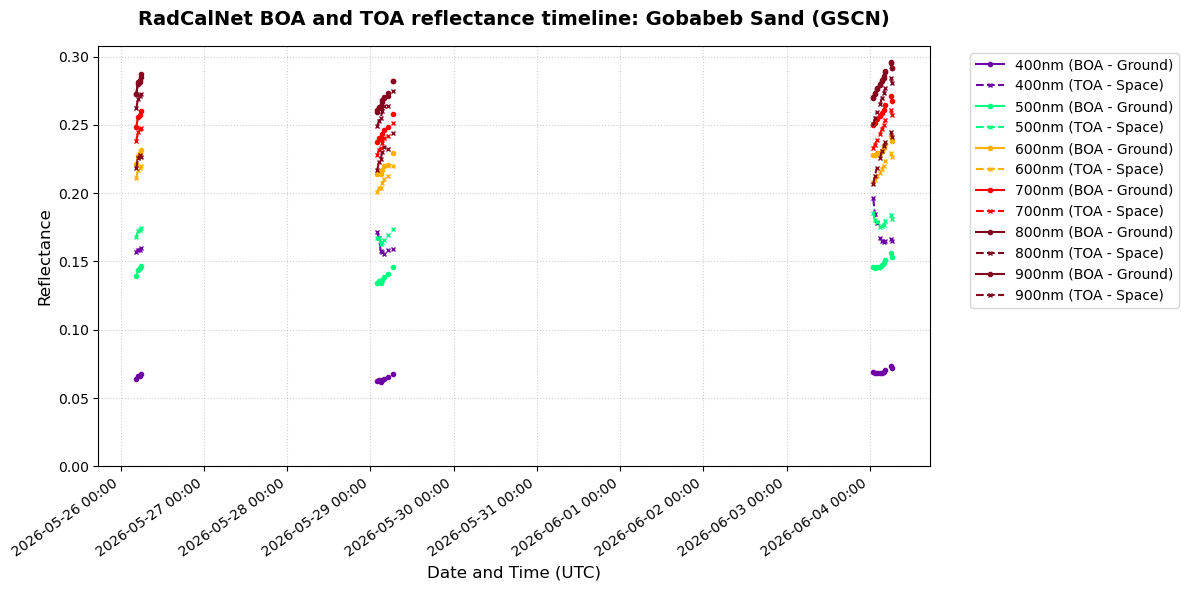

In [53]:
# Now define your target selection range
selected_wavelengths = [*range(500, 510, 10), *range(900, 910, 10)]
selected_wavelengths = [*range(400, 1000, 100)]


# Generate the plot
plot_boa_vs_toa_with_colors(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    wavelengths=selected_wavelengths,
    site_name=f"{SITE_CODE}",
)


In [54]:
in_ref_spectra.head()

,2026-05-03 01:00,2026-05-03 01:30,2026-05-03 02:00,2026-05-03 02:30,2026-05-03 03:00,2026-05-03 03:30,2026-05-03 04:00,2026-05-03 04:30,2026-05-03 05:00,2026-05-03 05:30,...,2026-06-05 02:30,2026-06-05 03:00,2026-06-05 03:30,2026-06-05 04:00,2026-06-05 04:30,2026-06-05 05:00,2026-06-05 05:30,2026-06-05 06:00,2026-06-05 06:30,2026-06-05 07:00
Wavelength,,,,,,,,,,,,,,,,,,,,,
400,0.0781,0.0762,0.0758,0.0757,0.0751,0.0752,0.0758,0.0767,0.0774,0.0781,...,0.0678,0.0689,0.0684,0.0701,0.0696,0.0719,0.0728,0.0727,0.0720,0.0712
410,0.0902,0.0881,0.0878,0.0877,0.0876,0.0880,0.0888,0.0899,0.0906,0.0913,...,0.0789,0.0804,0.0801,0.0822,0.0816,0.0842,0.0854,0.0853,0.0846,0.0837
420,0.1059,0.1038,0.1033,0.1033,0.1033,0.1039,0.1049,0.1061,0.1071,0.1078,...,0.0931,0.0949,0.0947,0.0972,0.0966,0.0996,0.1010,0.1009,0.1001,0.0990
430,0.1190,0.1167,0.1161,0.1162,0.1163,0.1169,0.1181,0.1193,0.1205,0.1213,...,0.1049,0.1070,0.1067,0.1096,0.1088,0.1123,0.1137,0.1137,0.1128,0.1115
440,0.1256,0.1234,0.1228,0.1228,0.1230,0.1237,0.1248,0.1261,0.1273,0.1282,...,0.1111,0.1133,0.1130,0.1160,0.1152,0.1188,0.1203,0.1202,0.1193,0.1179


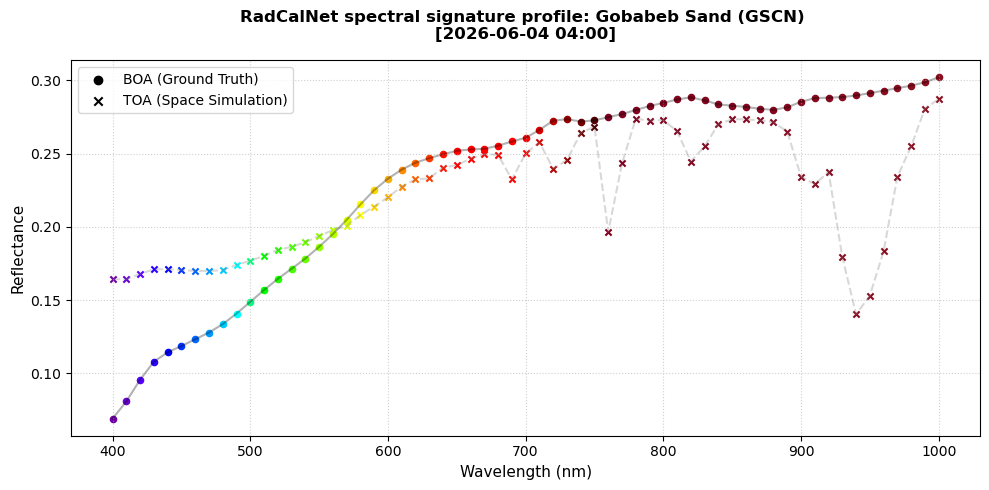

In [55]:
# Select a single date and time present in your dataset
target_time = "2026-06-04 04:00"

# Generate the plot
plot_spectral_signature_curve(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    timestamp_str=target_time,
    site_name=SITE_CODE
)


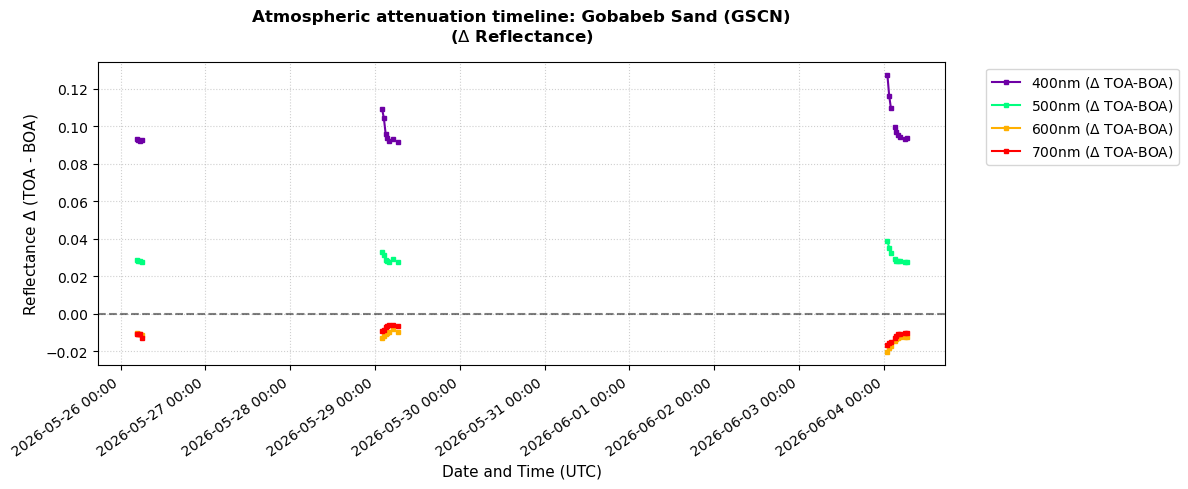

In [57]:
# Define your targets using the list unpacking method
selected_wavelengths = [*range(500, 700, 10), *range(900, 920, 10)] # [500, 510, 900, 910]
selected_wavelengths = [*range(400, 800, 100)] # [500, 510, 900, 910]

# Generate the plot
plot_atmospheric_attenuation(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    wavelengths=selected_wavelengths,
    site_name=SITE_CODE
)


--- Running Diurnal Trend Overlay for Ground View (BOA) ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


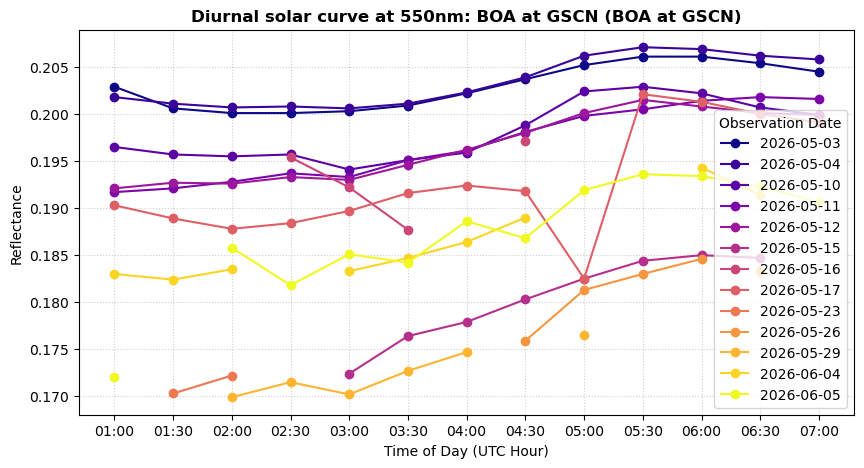


--- Running Diurnal Trend Overlay for Space View (TOA) ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


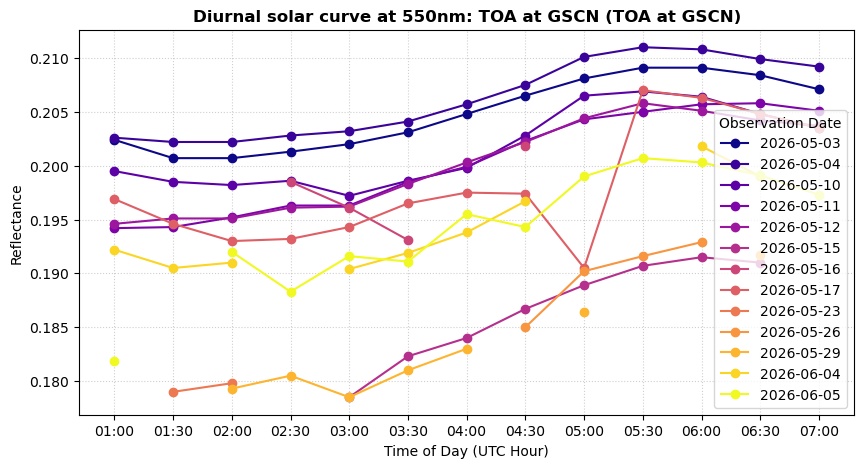

In [60]:
# Choose a single wavelength channel to analyze across all days
target_wavelength = 550  # Green band element

print("--- Running Diurnal Trend Overlay for Ground View (BOA) ---")
plot_diurnal_overlay(spectra_df=in_ref_spectra, wavelength=target_wavelength, site_name=f"BOA at {SITE_CODE}")

print("\n--- Running Diurnal Trend Overlay for Space View (TOA) ---")
plot_diurnal_overlay(spectra_df=out_ref_spectra, wavelength=target_wavelength, site_name=f"TOA at {SITE_CODE}")


### Functions to do multi-site plotting

In [158]:
!ls -d /projects/my-public-bucket/databank/radcalnet/*

/projects/my-public-bucket/databank/radcalnet/BSCN
/projects/my-public-bucket/databank/radcalnet/BTCN
/projects/my-public-bucket/databank/radcalnet/GONA
/projects/my-public-bucket/databank/radcalnet/GSCN
/projects/my-public-bucket/databank/radcalnet/LCFR
/projects/my-public-bucket/databank/radcalnet/RVUS


In [61]:
def load_site_dataset(base_data_dir, site_code, stage="input"):
    """Recursively walks through all year subdirectories for a specific site

    and transforms the data blocks into a standardized long-form dataframe.
    """
    site_root_dir = os.path.join(base_data_dir, site_code)

    if not os.path.exists(site_root_dir):
        print(f"Warning: Directory path does not exist: {site_root_dir}")
        return pd.DataFrame()

    stage_ext = stage.lower().replace(".", "")
    all_file_meta = []
    all_file_spec = []

    # Recursively search through all subfolders
    for root, dirs, files in os.walk(site_root_dir):
        for file in files:
            if file.lower().endswith(f".{stage_ext}"):
                file_path = os.path.join(root, file)

                # Parse file blocks using your function
                meta_blocks, spec_blocks = parse_multi_dataset_file(file_path)

                if len(meta_blocks) >= 1:
                    all_file_meta.extend(meta_blocks)
                    all_file_spec.extend(spec_blocks)

    if not all_file_spec:
        print(
            f"Warning: No valid '.{stage_ext}' files compiled for site {site_code}"
        )
        return pd.DataFrame()

    # Concatenate the flat list of DataFrames side-by-side
    spec_df = pd.concat(all_file_spec, axis=1, sort=False)

    # FIX: Call .round() directly on the series object, not on 'pd'
    spec_df.index = spec_df.index.to_series().round().astype(int)
    spec_df.columns = pd.to_datetime(spec_df.columns)

    # Reshape wide matrix to long-form data
    long_df = spec_df.reset_index().melt(
        id_vars="Wavelength", var_name="DateTime", value_name="Reflectance"
    )

    # Apply processing tags
    long_df["Site"] = site_code
    long_df["Stage"] = stage.upper()

    # Drop RadCalNet Fill/NoData flags (9997, 9998, 9999) from calculations
    long_df = long_df[long_df["Reflectance"] < 2.0]

    return long_df

import matplotlib.pyplot as plt
import pandas as pd


import matplotlib.pyplot as plt
import pandas as pd

def plot_multi_site_timelines_with_colors(master_df, wavelengths):
    """
    Cycles through your long master dataframe by site code, maps the short
    code to its descriptive name, and routes data frames into the core function.
    """
    for site_code in master_df["Site"].unique():
        # Retrieve the long human-readable name or fallback to the code string
        descriptive_name = SITE_CODE_TO_NAME.get(site_code, site_code)
        
        # Isolate the dataset for the current station
        site_df = master_df[master_df["Site"] == site_code]

        in_data = site_df[site_df["Stage"] == "INPUT"]
        out_data = site_df[site_df["Stage"] == "OUTPUT"]

        if in_data.empty or out_data.empty:
            continue

        in_wide = in_data.pivot_table(index="Wavelength", columns="DateTime", values="Reflectance", aggfunc="first")
        out_wide = out_data.pivot_table(index="Wavelength", columns="DateTime", values="Reflectance", aggfunc="first")

        # Call your updated core routine passing the resolved site text name
        plot_boa_vs_toa_with_colors(
            input_spectra=in_wide,
            output_spectra=out_wide,
            wavelengths=wavelengths,
            site_name=descriptive_name
        )

def plot_multi_site_signatures(master_df, target_date_str):
    """Finds the closest operational data overpass matching your target date

    for each individual site, and prints its continuous wavelength signature.
    """
    target_dt = pd.to_datetime(target_date_str)

    for site_code in master_df["Site"].unique():
        descriptive_name = SITE_CODE_TO_NAME.get(site_code, site_code)
        site_df = master_df[master_df["Site"] == site_code]

        # Isolate site specific timestamps
        available_times = pd.to_datetime(site_df["DateTime"].unique())

        if len(available_times) == 0:
            continue

        # Find the absolute closest observation time available at this site
        closest_time = available_times[np.argmin(np.abs(available_times - target_dt))]
        closest_time_str = closest_time.strftime("%Y-%m-%d %H:%M")

        print(f"\nSite {site_code}: Target date is {target_date_str}.")
        print(f"-> Closest available record found at: {closest_time_str}")

        # Build wide tables
        in_wide = (
            site_df[site_df["Stage"] == "INPUT"]
            .pivot_table(
                index="Wavelength",
                columns="DateTime",
                values="Reflectance",
                aggfunc="first",
            )
        )
        out_wide = (
            site_df[site_df["Stage"] == "OUTPUT"]
            .pivot_table(
                index="Wavelength",
                columns="DateTime",
                values="Reflectance",
                aggfunc="first",
            )
        )

        # Call your original curve profile tool
        plot_spectral_signature_curve(
            input_spectra=in_wide,
            output_spectra=out_wide,
            timestamp_str=closest_time,  # Pass the datetime object or exact matching string
            site_name=descriptive_name
        )



def plot_multi_site_attenuation(master_df, wavelengths):
    """Generates pure atmospheric distortion delta graphs per station."""
    for site_code in master_df["Site"].unique():
        descriptive_name = SITE_CODE_TO_NAME.get(site_code, site_code)
        site_df = master_df[master_df["Site"] == site_code]

        in_wide = (
            site_df[site_df["Stage"] == "INPUT"]
            .pivot_table(
                index="Wavelength",
                columns="DateTime",
                values="Reflectance",
                aggfunc="first",
            )
        )
        out_wide = (
            site_df[site_df["Stage"] == "OUTPUT"]
            .pivot_table(
                index="Wavelength",
                columns="DateTime",
                values="Reflectance",
                aggfunc="first",
            )
        )

        plot_atmospheric_attenuation(
            input_spectra=in_wide,
            output_spectra=out_wide,
            wavelengths=wavelengths,
            site_name=descriptive_name
        )


def plot_multi_site_diurnal(master_df, target_wavelength):
    """Overlays diurnal solar cycle profiles sorted by date for each site location."""
    for site_code in master_df["Site"].unique():
        descriptive_name = SITE_CODE_TO_NAME.get(site_code, site_code)
        site_df = master_df[master_df["Site"] == site_code]

        # Extract stages independently
        in_wide = (
            site_df[site_df["Stage"] == "INPUT"]
            .pivot_table(
                index="Wavelength",
                columns="DateTime",
                values="Reflectance",
                aggfunc="first",
            )
        )

        print(f"\n--- Diurnal Ground Trend (BOA) for Station: {site_code} ---")
        plot_diurnal_overlay(spectra_df=in_wide, wavelength=target_wavelength, site_name=descriptive_name)


In [64]:
DATADIR

'/explore/nobackup/projects/CSDA_eval/data/radcalnet'

In [65]:
# 2. Define the complete list of 4-letter RadCalNet station codes
site_codes = ["BSCN", "BTCN", "GONA", "GSCN", "LCFR", "RVUS"]

# 3. Initialize an empty list to gather the individual long-form frames
all_sites_compiled = []

print("Starting master compilation loop across all RadCalNet directories...\n")

for site in site_codes:
    print(f"-> Extracting and parsing data for site station: {site}")
    
    # Extract Ground measurements (BOA)
    site_boa = load_site_dataset(DATADIR, site, stage="input")
    
    # Extract Space-view simulations (TOA)
    site_toa = load_site_dataset(DATADIR, site, stage="output")
    
    # Only collect data frames if the site folders contained valid, processed data files
    if not site_boa.empty:
        all_sites_compiled.append(site_boa)
    if not site_toa.empty:
        all_sites_compiled.append(site_toa)

# 4. Concatenate all rows together into one massive long-form database
if all_sites_compiled:
    master_spectral_df = pd.concat(all_sites_compiled, axis=0, ignore_index=True)
    print("\n======================================================")
    print(" COMPILATION COMPLETE SUCCESSFULLY!")
    print(f" Total rows in global database: {master_spectral_df.shape[0]:,}")
    print(f" Unique stations successfully mapped: {master_spectral_df['Site'].unique().tolist()}")
    print("======================================================")
else:
    print("\nError: No valid spectral data frames could be compiled from the paths.")



Starting master compilation loop across all RadCalNet directories...

-> Extracting and parsing data for site station: BSCN
-> Extracting and parsing data for site station: BTCN
-> Extracting and parsing data for site station: GONA
-> Extracting and parsing data for site station: GSCN
-> Extracting and parsing data for site station: LCFR
-> Extracting and parsing data for site station: RVUS

 COMPILATION COMPLETE SUCCESSFULLY!
 Total rows in global database: 674,586
 Unique stations successfully mapped: ['BSCN', 'BTCN', 'GONA', 'GSCN', 'LCFR', 'RVUS']


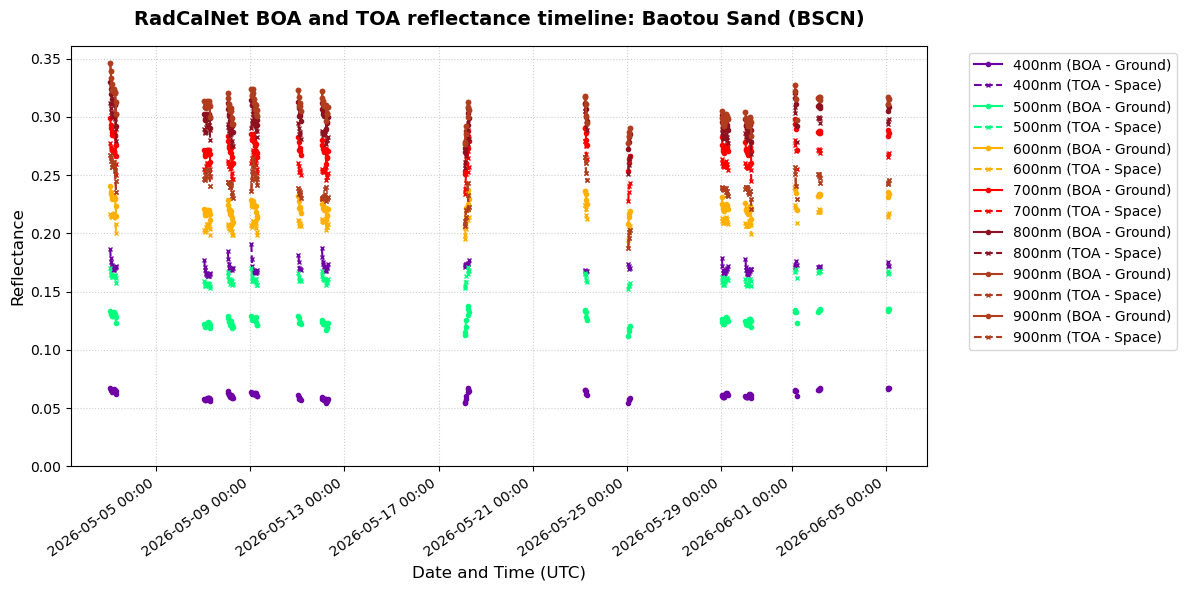

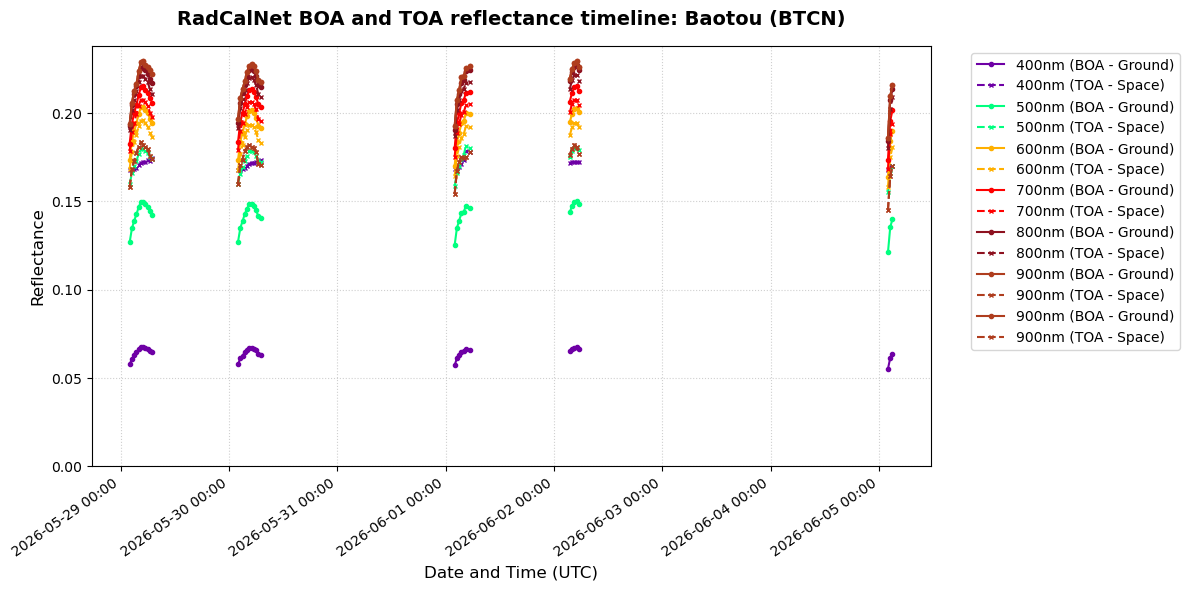

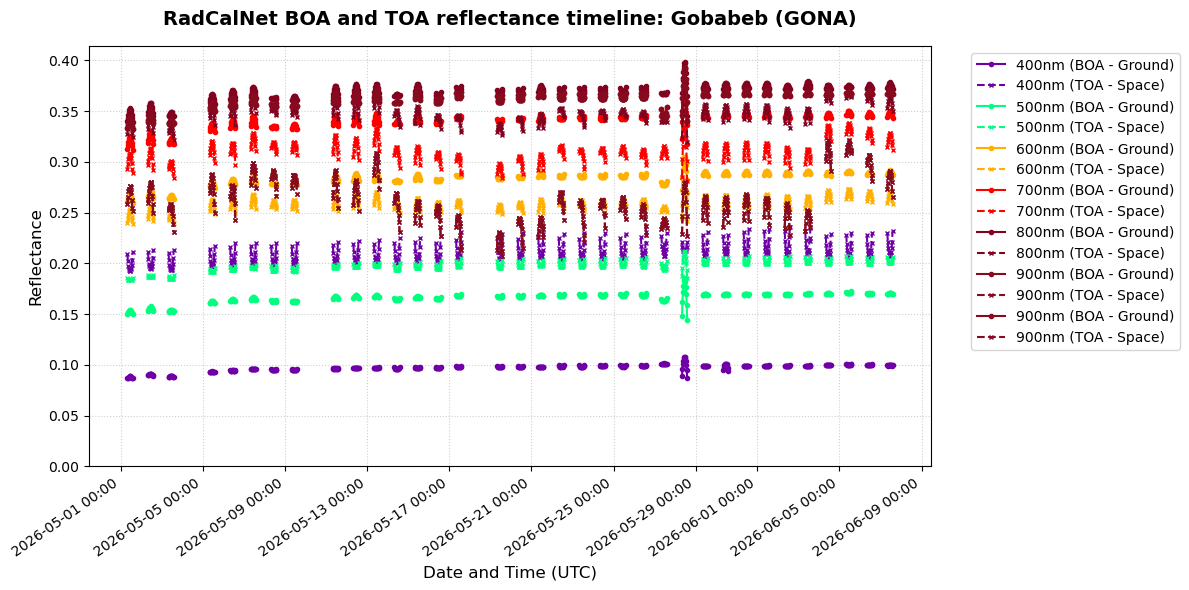

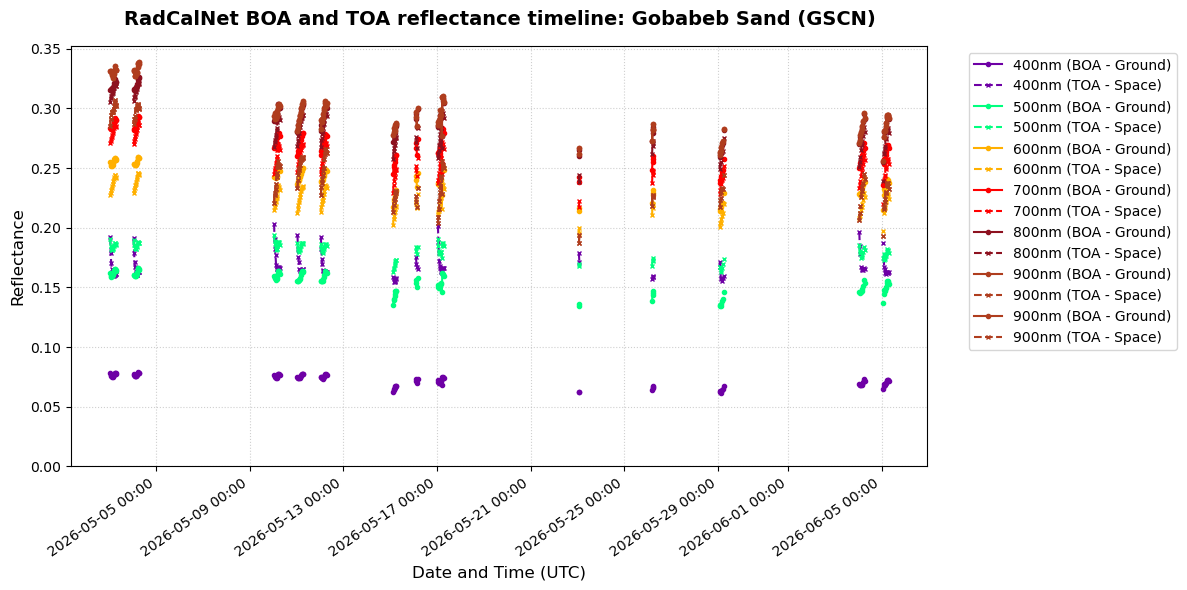

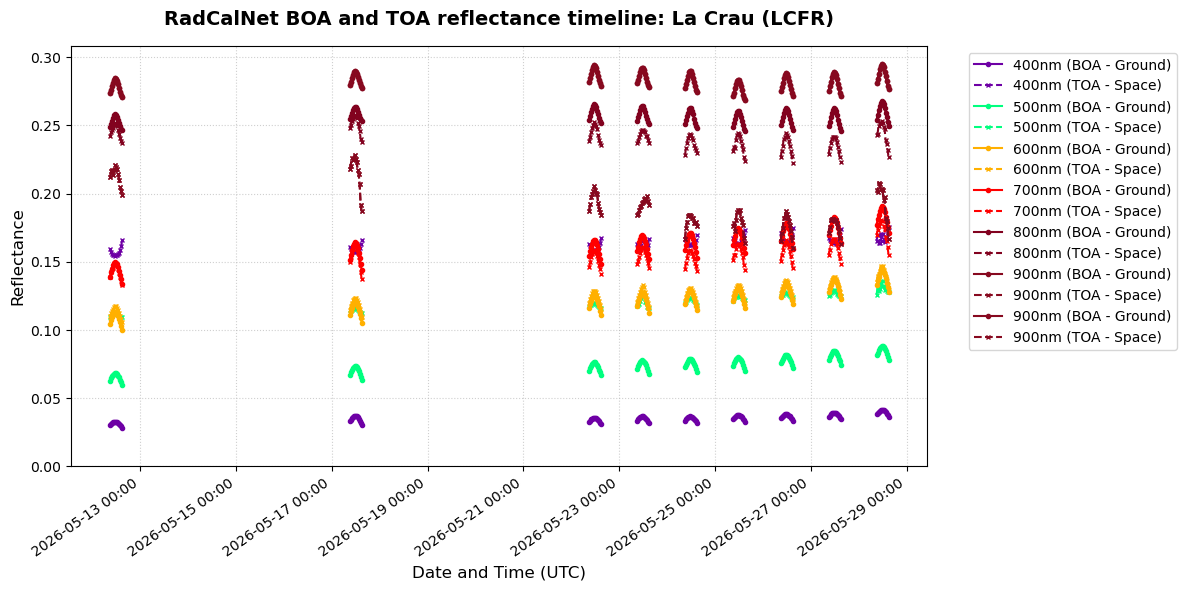

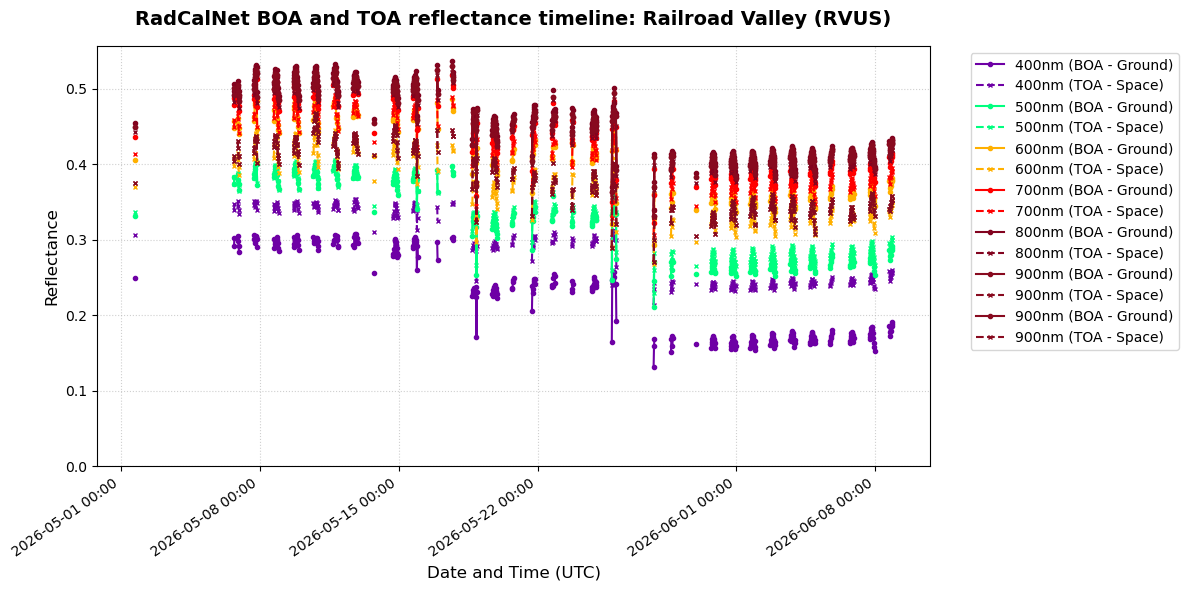


Site BSCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-02 03:30


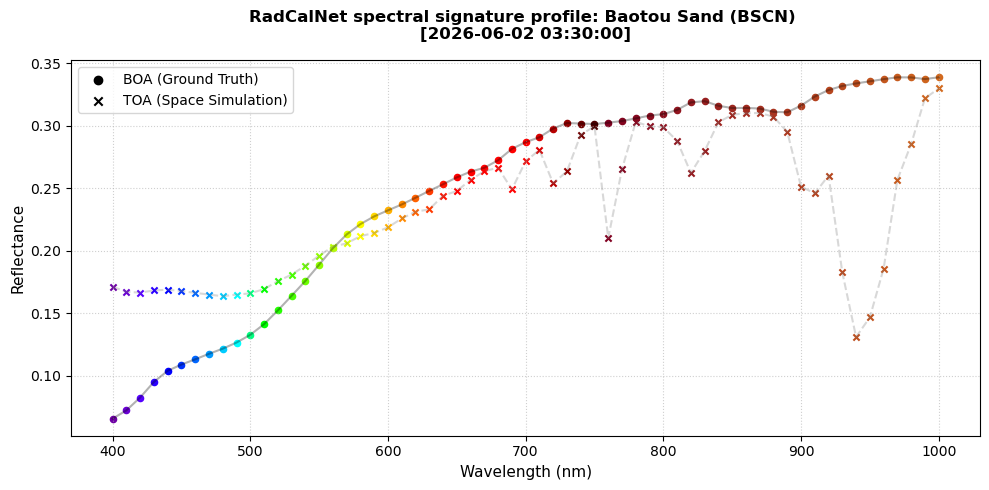


Site BTCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-02 03:30


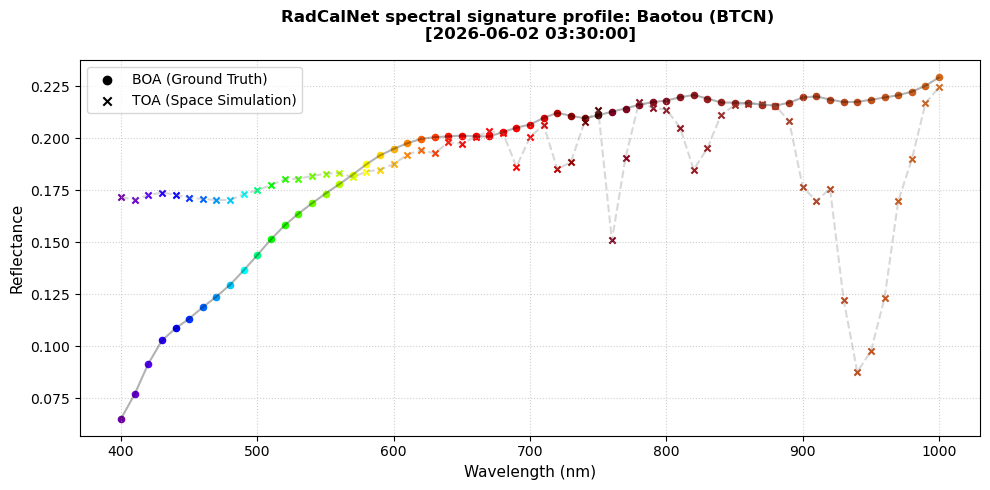


Site GONA: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-01 14:00


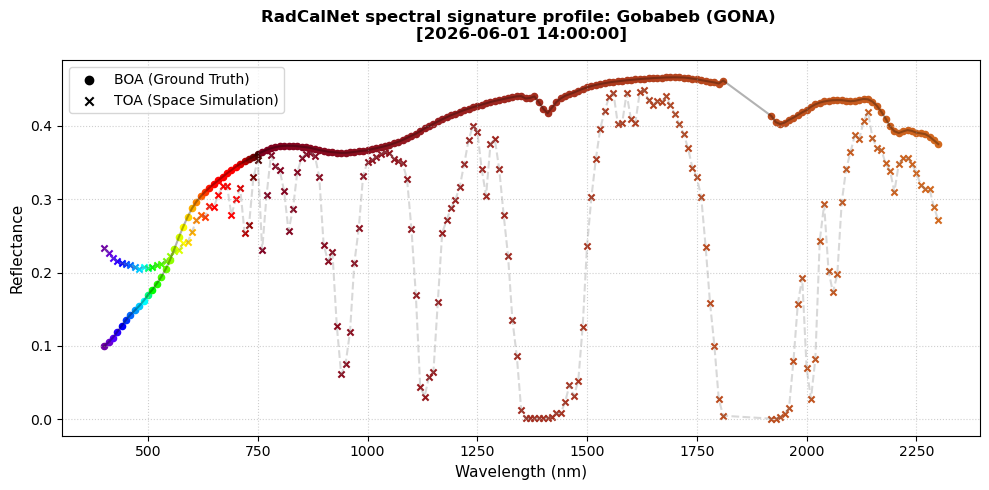


Site GSCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-04 01:00


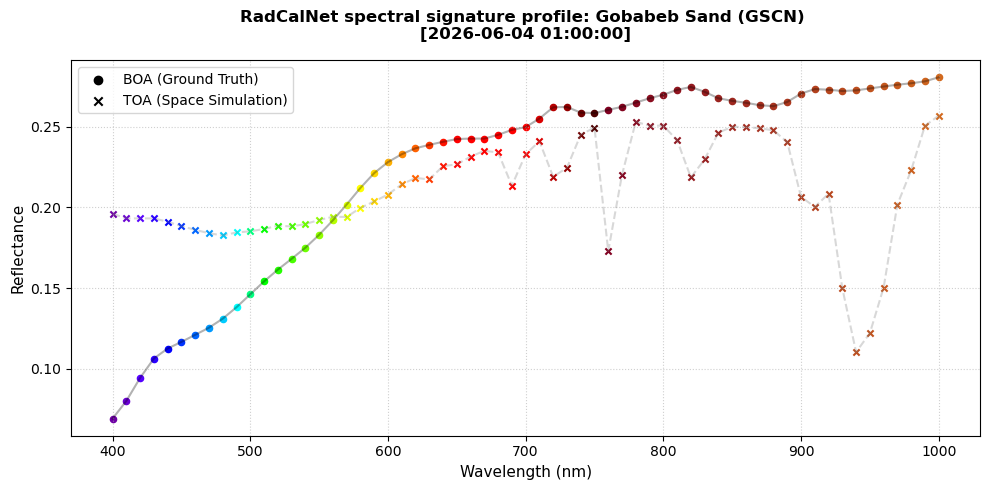


Site LCFR: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-05-28 15:00


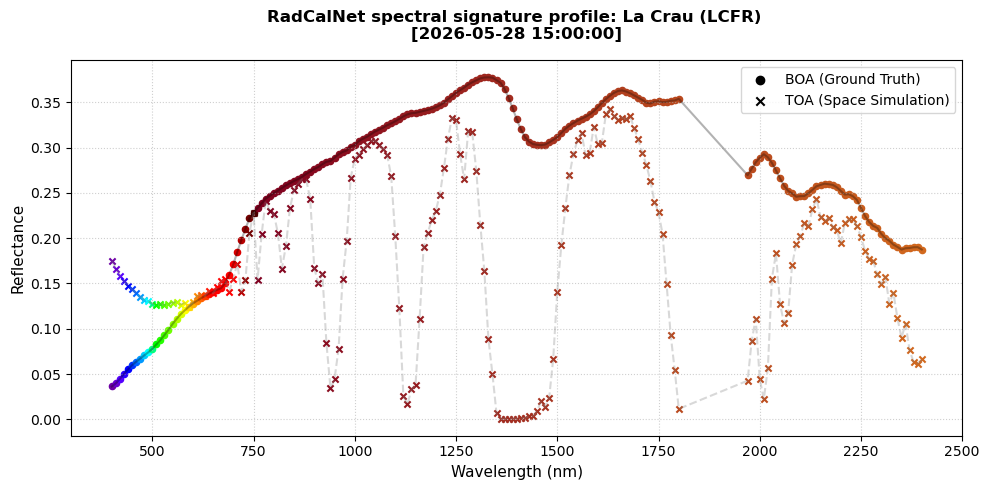


Site RVUS: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-01 17:00


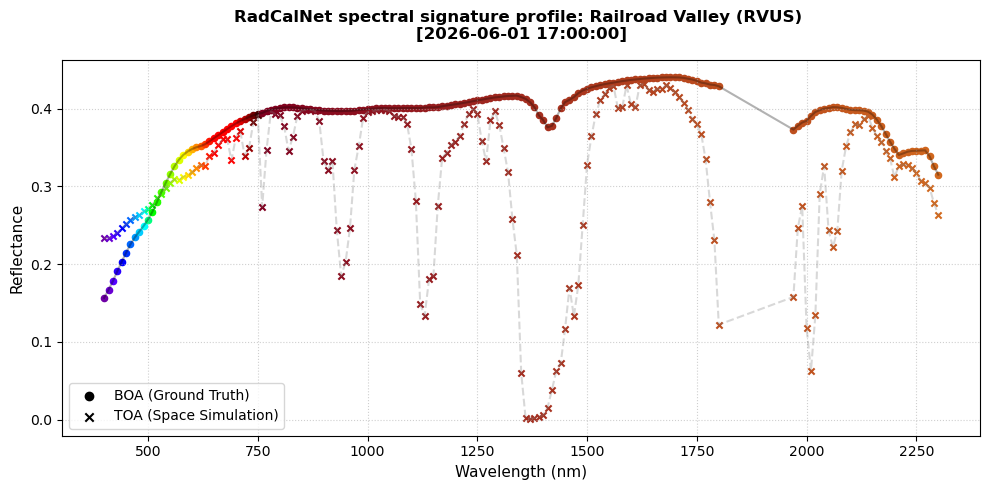

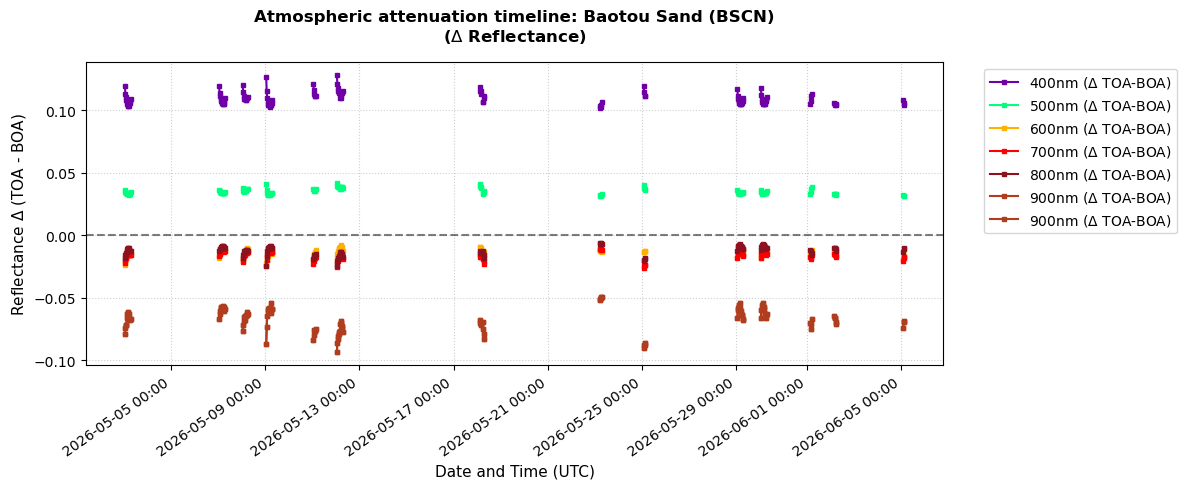

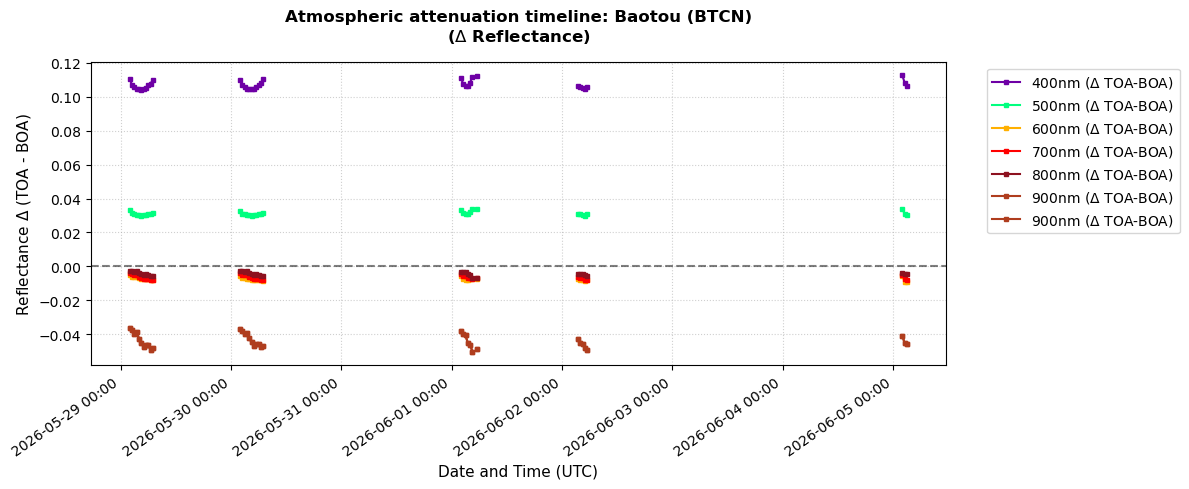

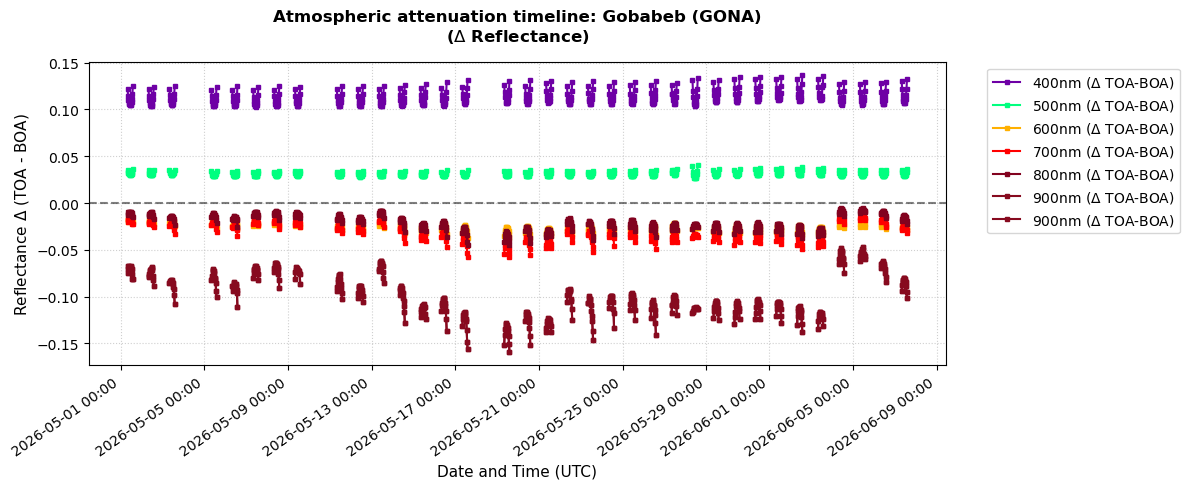

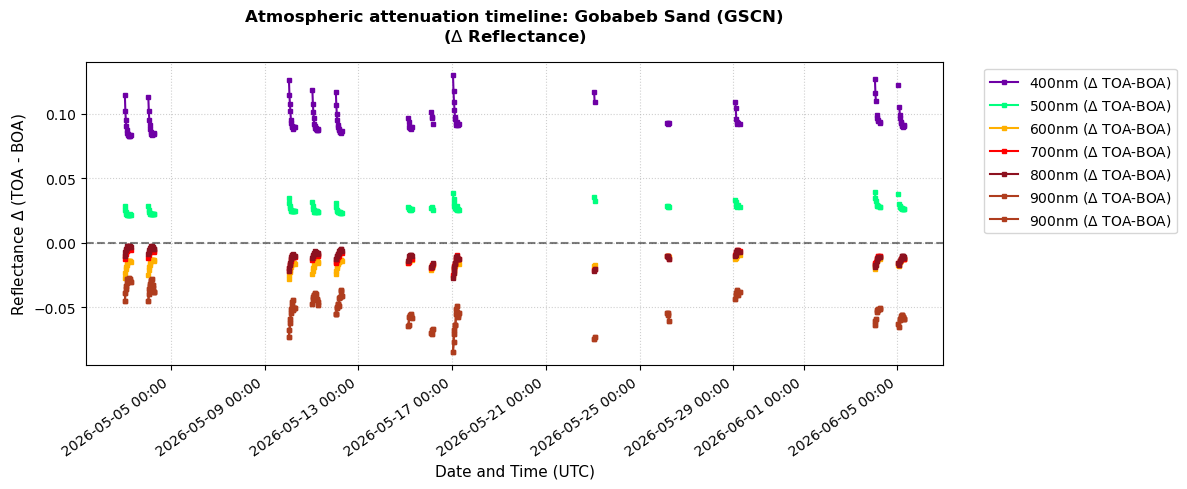

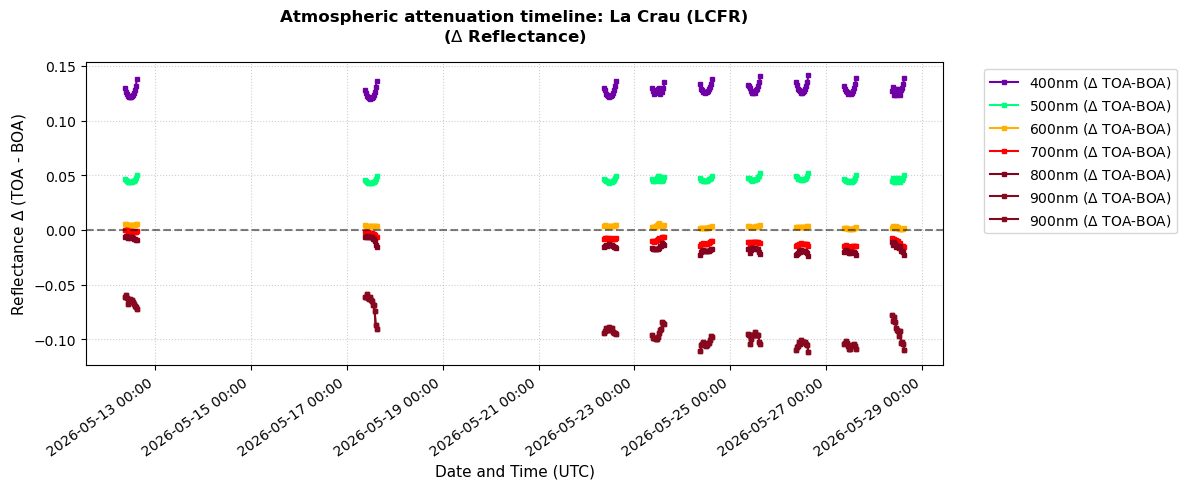

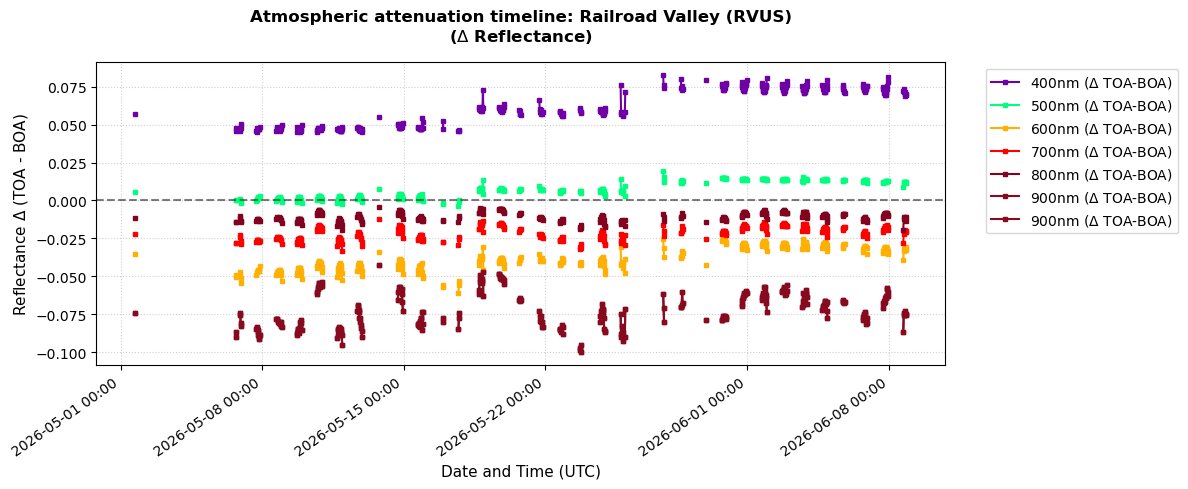


--- Diurnal Ground Trend (BOA) for Station: BSCN ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


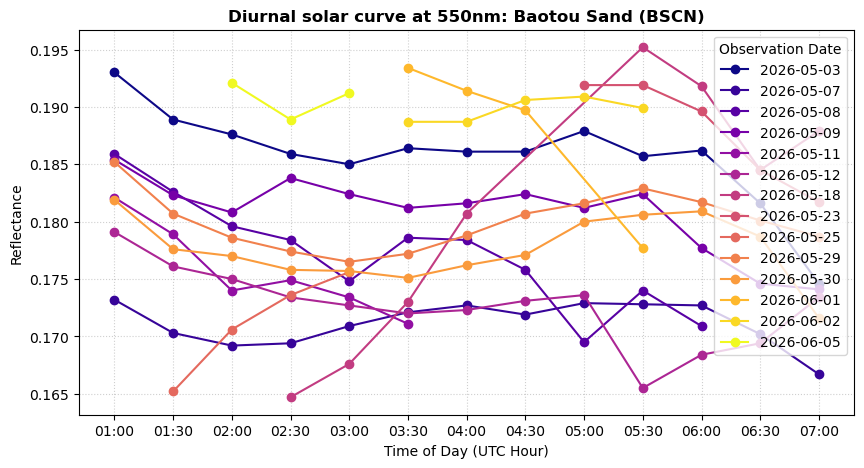


--- Diurnal Ground Trend (BOA) for Station: BTCN ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


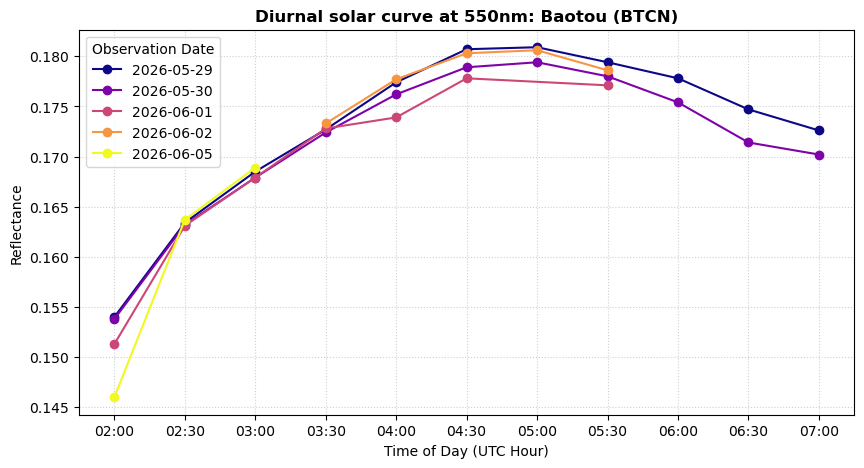


--- Diurnal Ground Trend (BOA) for Station: GONA ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


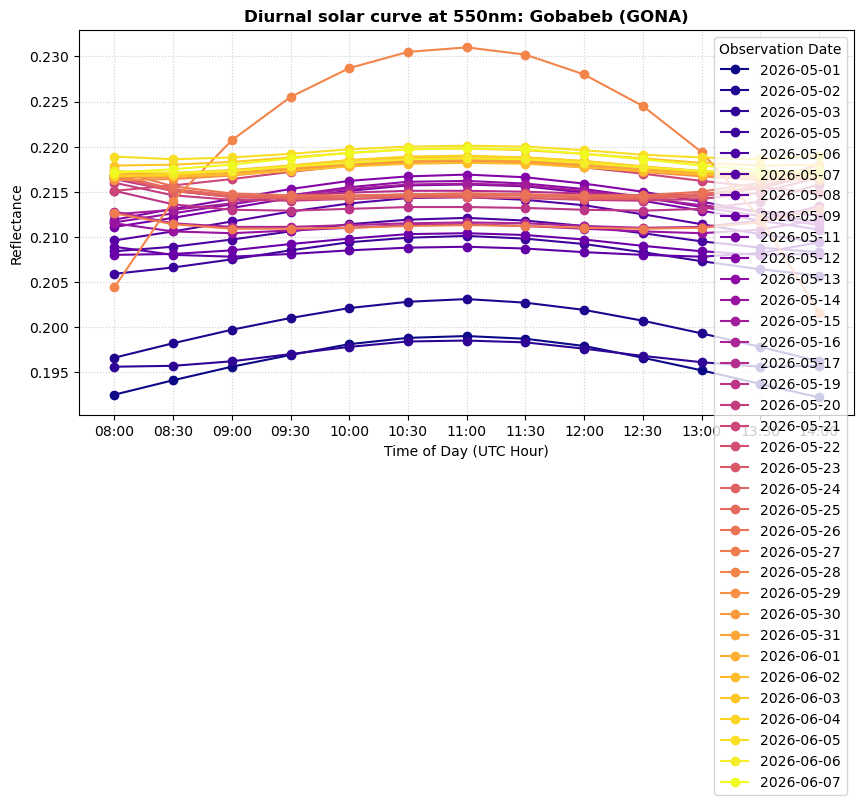


--- Diurnal Ground Trend (BOA) for Station: GSCN ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


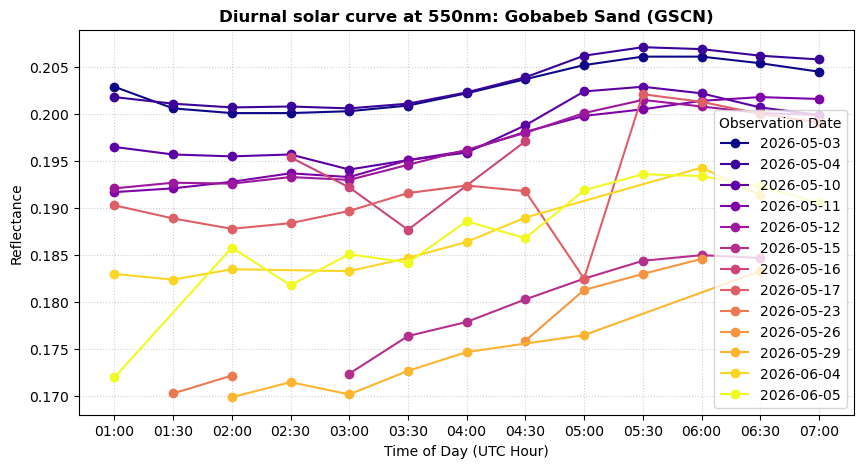


--- Diurnal Ground Trend (BOA) for Station: LCFR ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


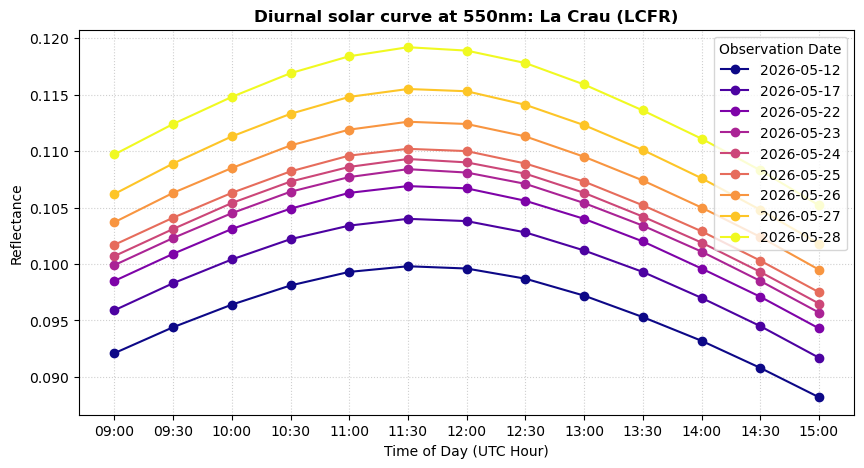


--- Diurnal Ground Trend (BOA) for Station: RVUS ---


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3668842/529766503.py:447: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('plasma', len(unique_dates))


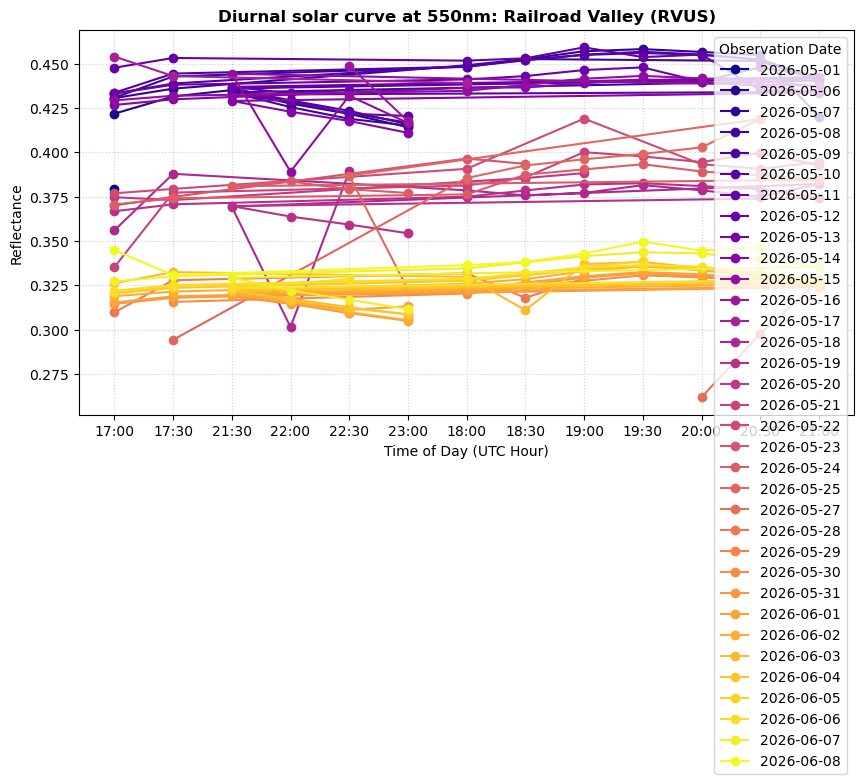

In [66]:
# Unpack your targeted bands across visible and infrared spectrums
target_bands = [*range(400, 1000, 100), *range(900, 910, 10)]

# 2. Run the timelines block
plot_multi_site_timelines_with_colors(master_spectral_df, wavelengths=target_bands)

# 3. Run full atmospheric absorption profiles for a date
plot_multi_site_signatures(master_spectral_df, target_date_str="2026-06-01 17:00")

# 4. Run delta timeline curves
plot_multi_site_attenuation(master_spectral_df, wavelengths=target_bands)

# 5. Run diurnal clock trends at 550nm
plot_multi_site_diurnal(master_spectral_df, target_wavelength=550)
